# Grid Codec — Inspect & Visualize

Encode Factorio game state as a 2D grid image and decode it back.

In [1]:
import sys
sys.path.insert(0, "../..")

from fle.grid_codec import encode, decode, EntitySpec, BoundingBox, ENTITY_REGISTRY
from fle.grid_codec.visualize import grid_to_machine, grid_to_human, CATEGORY_COLORS
from fle.grid_codec.schema import Meta
import numpy as np
from IPython.display import display

## Entity Registry

All placeable entities with their grid IDs, sizes, and metadata.

In [2]:
import polars as pl

rows = []
for info in ENTITY_REGISTRY.all_entities():
    flags = [f.name for f in Meta if f in info.meta and f.name != "NONE"]
    rows.append({
        "id": info.id,
        "name": info.name,
        "size": f"{info.width}x{info.height}",
        "category": info.category,
        "flags": ", ".join(flags) if flags else "-",
    })

df = pl.DataFrame(rows)
print(f"Total placeable entities: {len(df)}")
df

Total placeable entities: 75


id,name,size,category,flags
i64,str,str,str,str
1,"""burner-mining-drill""","""2x2""","""resource""","""IS_BURNER"""
2,"""electric-mining-drill""","""3x3""","""resource""","""IS_ELECTRIC"""
3,"""pumpjack""","""3x3""","""resource""","""IS_FLUID, IS_ELECTRIC"""
4,"""offshore-pump""","""1x2""","""resource""","""IS_FLUID"""
20,"""transport-belt""","""1x1""","""transport""","""IS_BELT"""
…,…,…,…,…
192,"""constant-combinator""","""1x1""","""circuit""","""IS_ELECTRIC"""
193,"""power-switch""","""2x2""","""circuit""","""IS_ELECTRIC"""
240,"""belt-group""","""1x1""","""special""","""IS_BELT"""


## Minimal Smelting Setup

Drill → inserter → furnace → belt. Encode, visualize, then decode back.

In [3]:
# Direction constants (FLE convention): 0=UP, 4=RIGHT, 8=DOWN, 12=LEFT
# For inserters: direction = where items are DROPPED (picks from opposite side)
# For belts: direction = item flow direction
# For drills: direction = where mined items are dropped
UP, RIGHT, DOWN, LEFT = 0, 4, 8, 12

# Smelting line flowing LEFT → RIGHT:
#   drill drops RIGHT → inserter picks LEFT, drops RIGHT → furnace → inserter drops RIGHT → belt goes RIGHT
smelting = [
    EntitySpec("burner-mining-drill", x=0, y=0, direction=RIGHT),   # 2x2, drops right
    EntitySpec("burner-inserter",     x=2, y=0, direction=RIGHT),   # picks left (drill), drops right (furnace)
    EntitySpec("stone-furnace",       x=3, y=0, direction=RIGHT),   # 2x2
    EntitySpec("burner-inserter",     x=5, y=0, direction=RIGHT),   # picks left (furnace), drops right (belt)
    EntitySpec("transport-belt",      x=6, y=0, direction=RIGHT),   # belt flows right
    EntitySpec("transport-belt",      x=6, y=1, direction=RIGHT),   # belt flows right
]

bounds = BoundingBox.from_entities(smelting, padding=1)
grid = encode(smelting, bounds=bounds)

print(f"Grid shape: {grid.shape}  (H={grid.shape[0]}, W={grid.shape[1]}, channels={grid.shape[2]})")
print(f"Bounds: x={bounds.x}, y={bounds.y}, {bounds.width}x{bounds.height} tiles")
print(f"Non-empty tiles: {np.count_nonzero(grid[:,:,0])}")

Grid shape: (4, 9, 4)  (H=4, W=9, channels=4)
Bounds: x=-1, y=-1, 9x4 tiles
Non-empty tiles: 12


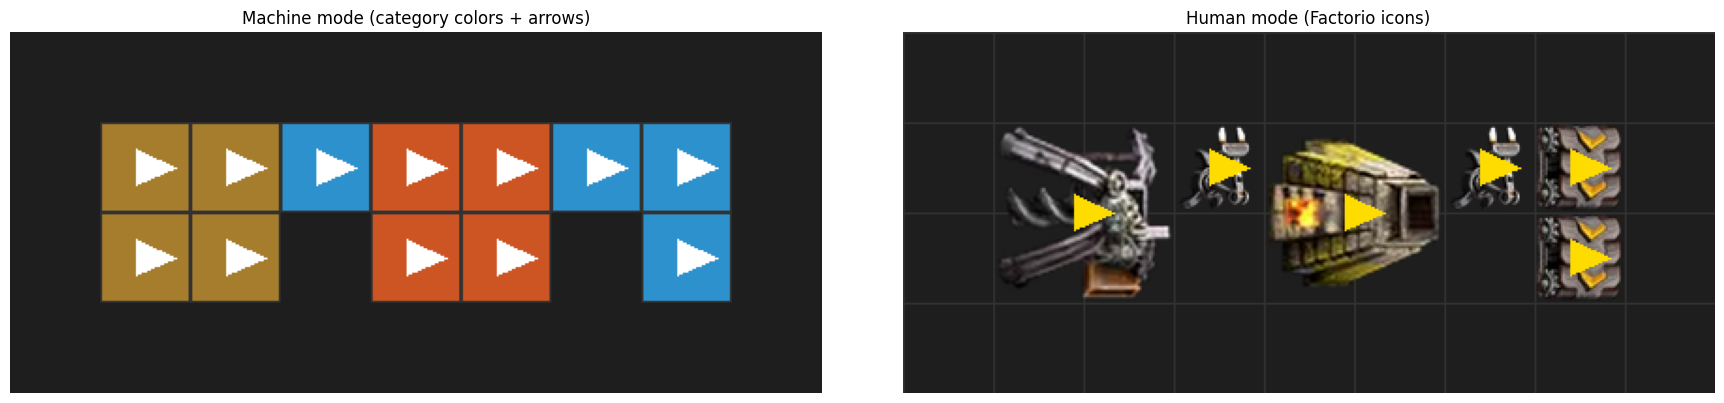

In [4]:
import matplotlib.pyplot as plt

machine_img = grid_to_machine(grid, scale=48)
human_img = grid_to_human(grid, data_dir="../../../data/2.0", scale=48)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 4))

ax1.imshow(machine_img)
ax1.set_title("Machine mode (category colors + arrows)")
ax1.axis("off")

ax2.imshow(human_img)
ax2.set_title("Human mode (Factorio icons)")
ax2.axis("off")

plt.tight_layout()
plt.show()

## Inspect Raw Channels

Look at each channel of the grid individually.

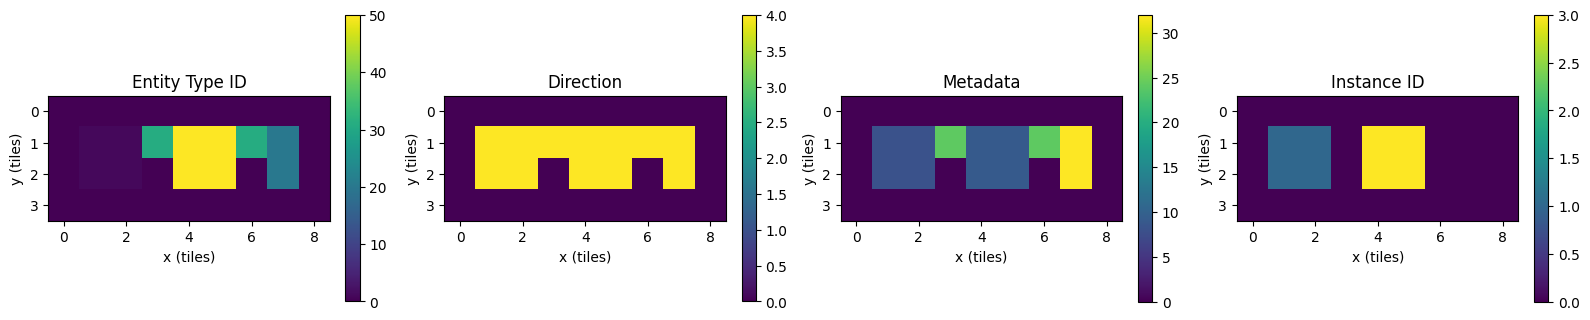

In [5]:
import matplotlib.pyplot as plt

channel_names = ["Entity Type ID", "Direction", "Metadata", "Instance ID"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, (ax, name) in enumerate(zip(axes, channel_names)):
    im = ax.imshow(grid[:, :, i], cmap="viridis", interpolation="nearest")
    ax.set_title(name)
    ax.set_xlabel("x (tiles)")
    ax.set_ylabel("y (tiles)")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

## Round-trip: Decode back to entities

Verify the grid decodes back to the same entity list.

In [6]:
decoded = decode(grid, bounds=bounds)

print(f"Original: {len(smelting)} entities")
print(f"Decoded:  {len(decoded)} entities\n")

for i, (orig, dec) in enumerate(zip(smelting, decoded)):
    match = "OK" if orig.name == dec.name and orig.x == dec.x and orig.y == dec.y else "MISMATCH"
    print(f"  [{match}] {dec.name:25s} pos=({dec.x},{dec.y}) dir={dec.direction}")

Original: 6 entities
Decoded:  6 entities

  [OK] burner-mining-drill       pos=(0,0) dir=4
  [OK] burner-inserter           pos=(2,0) dir=4
  [OK] stone-furnace             pos=(3,0) dir=4
  [OK] burner-inserter           pos=(5,0) dir=4
  [OK] transport-belt            pos=(6,0) dir=4
  [OK] transport-belt            pos=(6,1) dir=4


## Larger Blueprint: Oil Processing

Refinery + chemical plants + pipes — multi-tile entities and fluid connections.

Grid shape: (8, 16, 4)
Non-empty tiles: 69
Unique entity types: 5


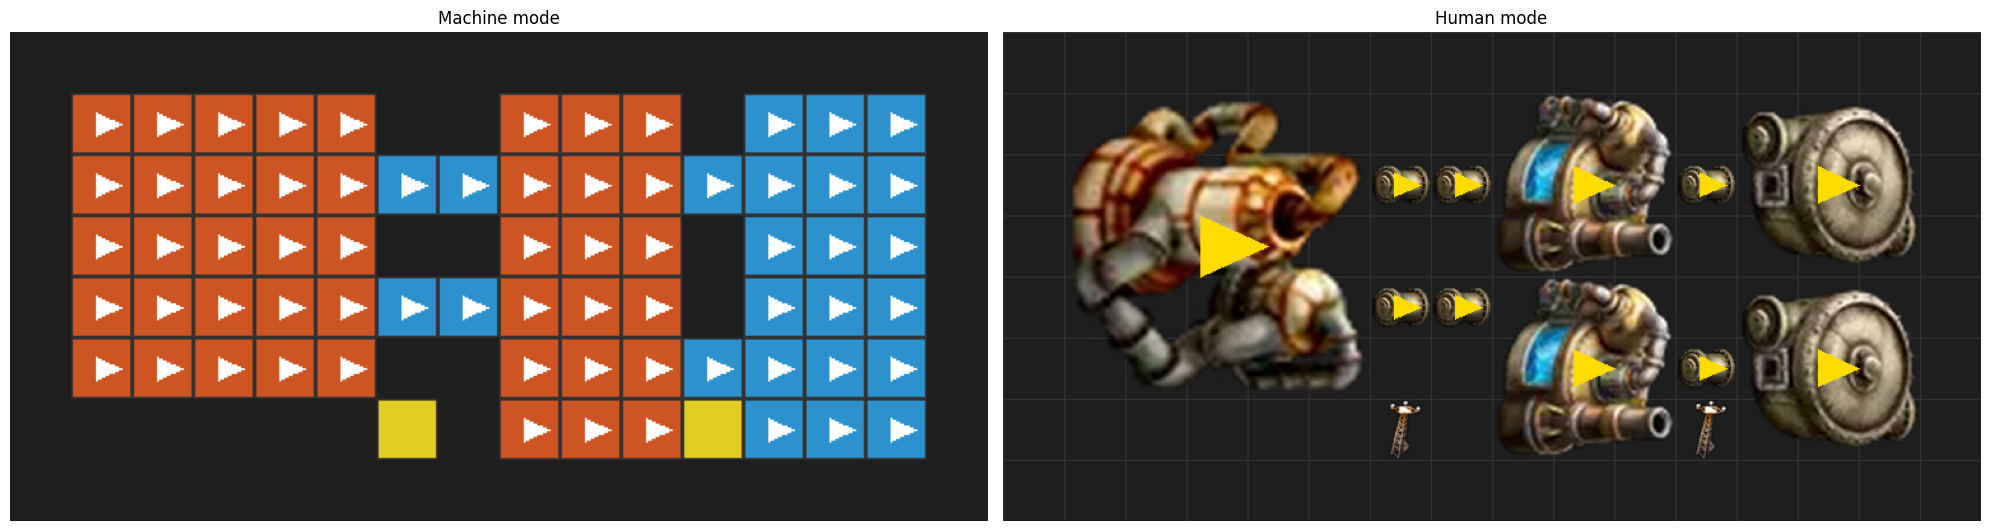

In [7]:
oil_setup = [
    # Refinery (5x5) — outputs flow right
    EntitySpec("oil-refinery", x=0, y=0, direction=RIGHT),

    # Pipes connecting refinery to chemical plants
    EntitySpec("pipe", x=5, y=1, direction=RIGHT),
    EntitySpec("pipe", x=6, y=1, direction=RIGHT),
    EntitySpec("pipe", x=5, y=3, direction=RIGHT),
    EntitySpec("pipe", x=6, y=3, direction=RIGHT),

    # Chemical plant 1 — heavy oil cracking (3x3)
    EntitySpec("chemical-plant", x=7, y=0, direction=RIGHT),

    # Chemical plant 2 — light oil cracking (3x3)
    EntitySpec("chemical-plant", x=7, y=3, direction=RIGHT),

    # Output pipes
    EntitySpec("pipe", x=10, y=1, direction=RIGHT),
    EntitySpec("pipe", x=10, y=4, direction=RIGHT),

    # Storage tanks
    EntitySpec("storage-tank", x=11, y=0, direction=RIGHT),  # 3x3
    EntitySpec("storage-tank", x=11, y=3, direction=RIGHT),  # 3x3

    # Power
    EntitySpec("medium-electric-pole", x=5, y=5, direction=UP),
    EntitySpec("medium-electric-pole", x=10, y=5, direction=UP),
]

bounds_oil = BoundingBox.from_entities(oil_setup, padding=1)
grid_oil = encode(oil_setup, bounds=bounds_oil)

print(f"Grid shape: {grid_oil.shape}")
print(f"Non-empty tiles: {np.count_nonzero(grid_oil[:,:,0])}")
print(f"Unique entity types: {len(np.unique(grid_oil[:,:,0])) - 1}")

machine_oil = grid_to_machine(grid_oil, scale=32)
human_oil = grid_to_human(grid_oil, data_dir="../../../data/2.0", scale=48)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

ax1.imshow(machine_oil)
ax1.set_title("Machine mode")
ax1.axis("off")

ax2.imshow(human_oil)
ax2.set_title("Human mode")
ax2.axis("off")

plt.tight_layout()
plt.show()

## Color Legend

In [8]:
for cat, (r, g, b) in CATEGORY_COLORS.items():
    block = f"\033[48;2;{r};{g};{b}m   \033[0m"
    print(f"  {block}  {cat}")

       resource
       transport
       production
       power
       logistics
       combat
       circuit
       special


## Grid as numpy — raw data inspection

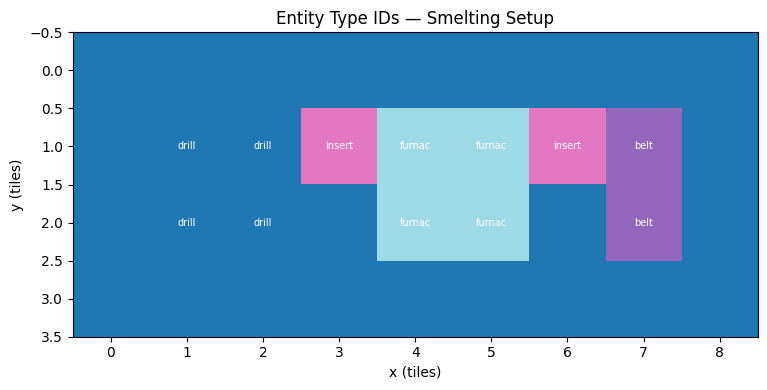

In [9]:
# Show entity type IDs in the smelting grid as a labeled heatmap
fig, ax = plt.subplots(figsize=(10, 4))
type_grid = grid[:, :, 0]

im = ax.imshow(type_grid, cmap="tab20", interpolation="nearest")
ax.set_title("Entity Type IDs — Smelting Setup")

# Annotate each cell with entity name
for gy in range(type_grid.shape[0]):
    for gx in range(type_grid.shape[1]):
        tid = type_grid[gy, gx]
        if tid > 0 and ENTITY_REGISTRY.has_id(int(tid)):
            name = ENTITY_REGISTRY.from_id(int(tid)).name.split("-")[-1][:6]
            ax.text(gx, gy, name, ha="center", va="center", fontsize=7, color="white")

ax.set_xlabel("x (tiles)")
ax.set_ylabel("y (tiles)")
plt.tight_layout()
plt.show()